In [1]:
# This Python 3 environment comes with many helpful analytics libraries installed
# It is defined by the kaggle/python Docker image: https://github.com/kaggle/docker-python
# For example, here's several helpful packages to load

import numpy as np # linear algebra
import pandas as pd # data processing, CSV file I/O (e.g. pd.read_csv)

# Input data files are available in the read-only "../input/" directory
# For example, running this (by clicking run or pressing Shift+Enter) will list all files under the input directory

import os
for dirname, _, filenames in os.walk('/kaggle/input'):
    for filename in filenames:
        print(os.path.join(dirname, filename))

# You can write up to 20GB to the current directory (/kaggle/working/) that gets preserved as output when you create a version using "Save & Run All" 
# You can also write temporary files to /kaggle/temp/, but they won't be saved outside of the current session

# Use the kagglehub client library to attach Kaggle resources like competitions, datasets, and models to your session
# Learn more about kagglehub: https://github.com/Kaggle/kagglehub/blob/main/README.md

import kagglehub
# kagglehub.dataset_download('<owner>/<dataset-slug>')

/kaggle/input/datasets/sushmithanarayan/expenses-receipt-ocr/X51005442344.jpg
/kaggle/input/datasets/sushmithanarayan/expenses-receipt-ocr/X51005719889.jpg
/kaggle/input/datasets/sushmithanarayan/expenses-receipt-ocr/X51005447853.jpg
/kaggle/input/datasets/sushmithanarayan/expenses-receipt-ocr/X51005453729.jpg
/kaggle/input/datasets/sushmithanarayan/expenses-receipt-ocr/X51005763940.jpg
/kaggle/input/datasets/sushmithanarayan/expenses-receipt-ocr/X51005711442.jpg
/kaggle/input/datasets/sushmithanarayan/expenses-receipt-ocr/X51005447859.jpg
/kaggle/input/datasets/sushmithanarayan/expenses-receipt-ocr/X51005441408.jpg
/kaggle/input/datasets/sushmithanarayan/expenses-receipt-ocr/X51005663274.jpg
/kaggle/input/datasets/sushmithanarayan/expenses-receipt-ocr/X51005719857.jpg
/kaggle/input/datasets/sushmithanarayan/expenses-receipt-ocr/X51005719863.jpg
/kaggle/input/datasets/sushmithanarayan/expenses-receipt-ocr/6.JPG
/kaggle/input/datasets/sushmithanarayan/expenses-receipt-ocr/X51005361897.j

In [2]:
import kagglehub

# Download latest version
path = kagglehub.dataset_download("sushmithanarayan/expenses-receipt-ocr")

print("Path to dataset files:", path)

Path to dataset files: /kaggle/input/datasets/sushmithanarayan/expenses-receipt-ocr


In [3]:
print(os.listdir("/kaggle/input/datasets/sushmithanarayan/expenses-receipt-ocr"))

['X51005442344.jpg', 'X51005719889.jpg', 'X51005447853.jpg', 'X51005453729.jpg', 'X51005763940.jpg', 'X51005711442.jpg', 'X51005447859.jpg', 'X51005441408.jpg', 'X51005663274.jpg', 'X51005719857.jpg', 'X51005719863.jpg', '6.JPG', 'X51005361897.jpg', 'X51005715007.jpg', 'X51005677329.jpg', 'X51005444046.jpg', 'X51005442378.jpg', 'X51005675104.jpg', 'X51005745190.jpg', 'X00016469623.jpg', 'X51005724627.jpg', 'X51005444041.jpg', 'X51005806679.jpg', 'X51005745183.jpg', 'X51005746210.jpg', 'X51005433522.jpg', 'X51005663280.jpg', '5.jpg', '8.jpg', 'X51005711454.jpg', 'X51005806692.jpg', 'X51005442338.jpg', 'X51005663276.jpg', 'X51005361907.jpg', 'X51005365179.jpg', 'X51005711445.jpg', 'X51005717526.jpg', 'X51005447851.jpg', 'X51005663277.jpg', 'X51005757349.jpg', 'X51005447841.jpg', 'X51005745187.jpg', 'X00016469676.jpg', 'X51005763958.jpg', 'X51005444044.jpg', 'X00016469622.jpg', 'X51005301661.jpg', 'X51005676546.jpg', 'X51005685355.jpg', 'X51005719864.jpg', 'X51005676541.jpg', 'X5100575735

In [4]:
DATASET_PATH = "/kaggle/input/datasets/sushmithanarayan/expenses-receipt-ocr"

print(os.listdir(DATASET_PATH))

['X51005442344.jpg', 'X51005719889.jpg', 'X51005447853.jpg', 'X51005453729.jpg', 'X51005763940.jpg', 'X51005711442.jpg', 'X51005447859.jpg', 'X51005441408.jpg', 'X51005663274.jpg', 'X51005719857.jpg', 'X51005719863.jpg', '6.JPG', 'X51005361897.jpg', 'X51005715007.jpg', 'X51005677329.jpg', 'X51005444046.jpg', 'X51005442378.jpg', 'X51005675104.jpg', 'X51005745190.jpg', 'X00016469623.jpg', 'X51005724627.jpg', 'X51005444041.jpg', 'X51005806679.jpg', 'X51005745183.jpg', 'X51005746210.jpg', 'X51005433522.jpg', 'X51005663280.jpg', '5.jpg', '8.jpg', 'X51005711454.jpg', 'X51005806692.jpg', 'X51005442338.jpg', 'X51005663276.jpg', 'X51005361907.jpg', 'X51005365179.jpg', 'X51005711445.jpg', 'X51005717526.jpg', 'X51005447851.jpg', 'X51005663277.jpg', 'X51005757349.jpg', 'X51005447841.jpg', 'X51005745187.jpg', 'X00016469676.jpg', 'X51005763958.jpg', 'X51005444044.jpg', 'X00016469622.jpg', 'X51005301661.jpg', 'X51005676546.jpg', 'X51005685355.jpg', 'X51005719864.jpg', 'X51005676541.jpg', 'X5100575735

In [5]:
import os

image_files = []

for root, dirs, files in os.walk(DATASET_PATH):
    for file in files:
        if file.lower().endswith((".jpg", ".jpeg", ".png")):
            image_files.append(os.path.join(root, file))

print("Number of receipt images:", len(image_files))
print("First 5 images:")

for path in image_files[:5]:
    print(path)

Number of receipt images: 371
First 5 images:
/kaggle/input/datasets/sushmithanarayan/expenses-receipt-ocr/X51005442344.jpg
/kaggle/input/datasets/sushmithanarayan/expenses-receipt-ocr/X51005719889.jpg
/kaggle/input/datasets/sushmithanarayan/expenses-receipt-ocr/X51005447853.jpg
/kaggle/input/datasets/sushmithanarayan/expenses-receipt-ocr/X51005453729.jpg
/kaggle/input/datasets/sushmithanarayan/expenses-receipt-ocr/X51005763940.jpg


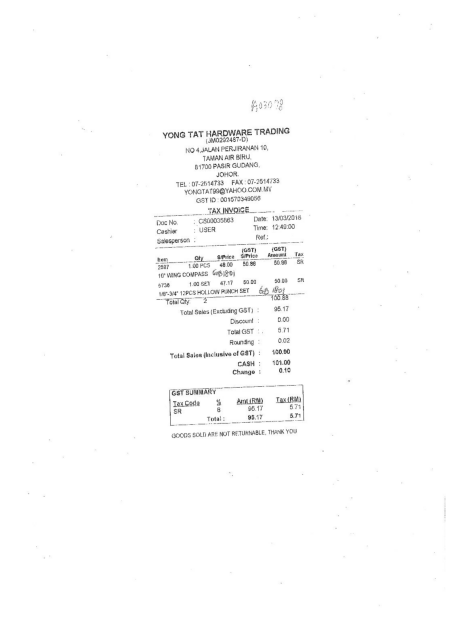

Image path: /kaggle/input/datasets/sushmithanarayan/expenses-receipt-ocr/X51005442344.jpg
Image size: (1080, 1527)


In [6]:
from PIL import Image
import matplotlib.pyplot as plt

image_path = image_files[0]

image = Image.open(image_path)

plt.figure(figsize=(12, 8))
plt.imshow(image)
plt.axis("off")
plt.show()

print("Image path:", image_path)
print("Image size:", image.size)

In [1]:
!pip install -q easyocr

import cv2
import easyocr
import matplotlib.pyplot as plt
import numpy as np
import os
import shutil

# 1. Load pretrained Deep Learning OCR model
reader = easyocr.Reader(['en'], gpu=True)

# 2. Improve receipt image before OCR
def prepare_receipt(image_path):
    image = cv2.imread(image_path)

    gray = cv2.cvtColor(image, cv2.COLOR_BGR2GRAY)

    # Improve contrast for faded receipt text
    clahe = cv2.createCLAHE(clipLimit=2.0, tileGridSize=(8, 8))
    clearer = clahe.apply(gray)

    # Enlarge image so small prices are easier to read
    clearer = cv2.resize(
        clearer,
        None,
        fx=2,
        fy=2,
        interpolation=cv2.INTER_CUBIC
    )

    return cv2.cvtColor(clearer, cv2.COLOR_GRAY2RGB)


# Choose one receipt image from your dataset
image_path = image_files[0]

processed_image = prepare_receipt(image_path)

# 3. Run EasyOCR
result = reader.readtext(
    processed_image,
    detail=1,
    paragraph=False,
    decoder="beamsearch",
    contrast_ths=0.05,
    adjust_contrast=0.7,
    mag_ratio=2
)

# 4. Show image used by the model
plt.figure(figsize=(12, 8))
plt.imshow(processed_image)
plt.axis("off")
plt.show()

# 5. Show exactly what the pretrained model read
print("EasyOCR results:")
for box, text, confidence in result:
    print(f"{text} | confidence: {confidence}")

# 6. Save the pretrained model files for Streamlit
source = "/root/.EasyOCR/model"
destination = "/kaggle/working/easyocr_model"

shutil.copytree(source, destination, dirs_exist_ok=True)

print("\nSaved EasyOCR model files:")
print(os.listdir(destination))

NameError: name 'image_files' is not defined

In [8]:
for root, dirs, files in os.walk("/kaggle/working"):
    level = root.replace("/kaggle/working", "").count(os.sep)
    indent = "  " * level
    print(f"{indent}{os.path.basename(root)}/")
    for file in files:
        print(f"{indent}  {file}")

working/
  .virtual_documents/
  easyocr_model/
    english_g2.pth
    craft_mlt_25k.pth
    latin_g2.pth


In [9]:
def prepare_receipt(image_path):
    image = cv2.imread(image_path)

    gray = cv2.cvtColor(image, cv2.COLOR_BGR2GRAY)

    clahe = cv2.createCLAHE(
        clipLimit=2.0,
        tileGridSize=(8, 8)
    )
    enhanced = clahe.apply(gray)

    enhanced = cv2.resize(
        enhanced,
        None,
        fx=2,
        fy=2,
        interpolation=cv2.INTER_CUBIC
    )

    return cv2.cvtColor(enhanced, cv2.COLOR_GRAY2RGB)

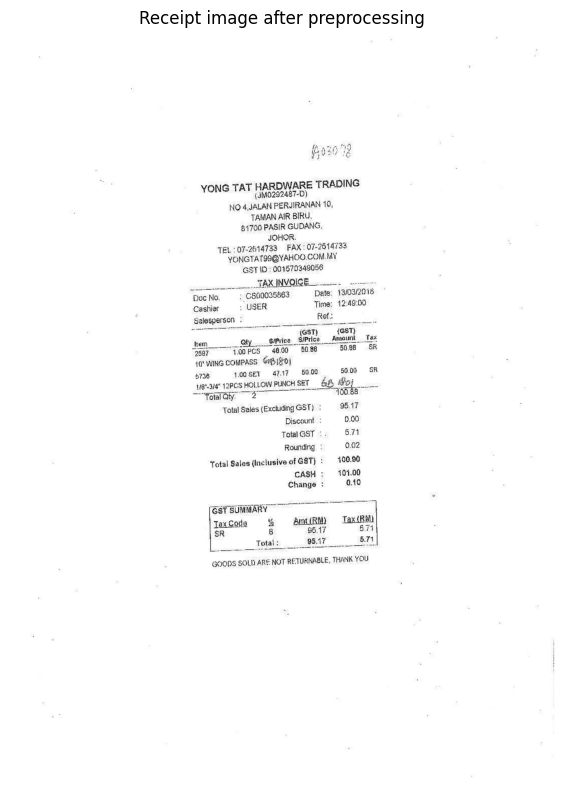

Raw EasyOCR output:
Yozc?2 | confidence: 0.12
YONG TAT HARPWARE TRADING | confidence: 0.67
(JM0292487-D} | confidence: 0.38
NO 4,JALAN PERJIRANAN 10, | confidence: 0.64
TAMAN AIR BIRU: | confidence: 0.50
81700 PASIR GUDANG, | confidence: 0.67
JOHOR | confidence: 0.36
TEL : 07-2614733 | confidence: 0.92
FAX : 07-2514733 | confidence: 0.51
YONGTATIA@YAHOO.CCM.MY | confidence: 0.26
GST ID : 001570349056 | confidence: 0.69
IAXINVQICE | confidence: 0.67
Doc No. | confidence: 0.44
CS00035863 | confidence: 0.68
Date: 13/03/2018 | confidence: 0.85
USER | confidence: 1.00
Time; | confidence: 0.69
12.49.00 | confidence: 0.42
Cashier | confidence: 0.96
Ref: | confidence: 0.54
Salesperson | confidence: 0.94
(GST) | confidence: 0.82
{GST) | confidence: 0.35
Sipidce | confidence: 0.21
Siprice | confidence: 0.62
Arnalint | confidence: 0.58
Tax | confidence: 1.00
Iterd | confidence: 0.65
Gty | confidence: 0.15
50.08 | confidence: 0.88
SR | confidence: 1.00
2597 | confidence: 1.00
1.00 PCS | confidence

In [ ]:
image_path = image_files[0]

prepared_image = prepare_receipt(image_path)

results = reader.readtext(
    prepared_image,
    detail=1,
    paragraph=False,
    decoder="beamsearch",
    contrast_ths=0.05,
    adjust_contrast=0.7,
    mag_ratio=2
)

plt.figure(figsize=(14, 10))
plt.imshow(prepared_image)
plt.axis("off")
plt.title("Receipt image after preprocessing")
plt.show()

print("Raw EasyOCR output:")
for box, text, confidence in results:
    print(f"{text} | confidence: {confidence}")

In [11]:
import re
import pandas as pd

PRICE_PATTERN = re.compile(
    r"(?:(?:BHD|B\.D\.|BD)\s*)?(\d{1,3}(?:[.,]\d{1,3}))",
    re.IGNORECASE
)

raw_ocr_data = []

for box, text, confidence in results:
    raw_ocr_data.append({
        "detected_text": text,
        "confidence": round(float(confidence), 2)
    })

ocr_table = pd.DataFrame(raw_ocr_data)

display(ocr_table)

,detected_text,confidence
0,Yozc?2,0.12
1,YONG TAT HARPWARE TRADING,0.67
2,(JM0292487-D},0.38
3,"NO 4,JALAN PERJIRANAN 10,",0.64
4,TAMAN AIR BIRU:,0.50
...,...,...
70,95.17,0.87
71,5.71,0.84
72,"GODS &OLI) ARE NOT RETURNABLE, THANK YOU",0.45
73,"3/4""",0.64


In [13]:
from pathlib import Path
import shutil

# EasyOCR downloads its pretrained files here after reader = easyocr.Reader(['en'])
source_folder = Path("/root/.EasyOCR/model")

# This is the folder you will use beside app.py
destination_folder = Path("/kaggle/working/easyocr_model")
destination_folder.mkdir(parents=True, exist_ok=True)

needed_files = [
    "latin_g2.pth",
    "english_g2.pth",
    "craft_mlt_25k.pth",
]

for filename in needed_files:
    source_file = source_folder / filename
    destination_file = destination_folder / filename

    if not source_file.exists():
        raise FileNotFoundError(f"Missing EasyOCR model file: {source_file}")

    shutil.copy2(source_file, destination_file)

print("Saved model files:")
for file in destination_folder.iterdir():
    print(file.name)

# Makes one file that is easy to download from Kaggle Output
shutil.make_archive(
    "/kaggle/working/easyocr_model",
    "zip",
    root_dir="/kaggle/working",
    base_dir="easyocr_model",
)

print("\nDownload this file from Kaggle Output:")
print("/kaggle/working/easyocr_model.zip")

Saved model files:
english_g2.pth
craft_mlt_25k.pth
latin_g2.pth

Download this file from Kaggle Output:
/kaggle/working/easyocr_model.zip


## evaluation

In [14]:
import tensorflow as tf
import matplotlib.pyplot as plt
import seaborn as sns

In [15]:
evaluation_data = pd.DataFrame({
    "product": [
        "Coca Cola",
        "Lays Chips",
        "Milk",
        "Water",
        "Bread",
        "Juice",
        "Chocolate",
        "Coffee"
    ],

    # 1 = price really increased
    # 0 = price did not increase
    "actual_label": [1, 0, 1, 0, 1, 0, 1, 0],

    # App prediction
    # 1 = app says increased
    # 0 = app says not increased
    "predicted_label": [1, 0, 1, 0, 0, 0, 1, 1]
})

evaluation_data

,product,actual_label,predicted_label
0,Coca Cola,1,1
1,Lays Chips,0,0
2,Milk,1,1
3,Water,0,0
4,Bread,1,0
5,Juice,0,0
6,Chocolate,1,1
7,Coffee,0,1


In [17]:
y_true = evaluation_data["actual_label"].astype("float32")
y_pred = evaluation_data["predicted_label"].astype("float32")

[[3 1]
 [1 3]]


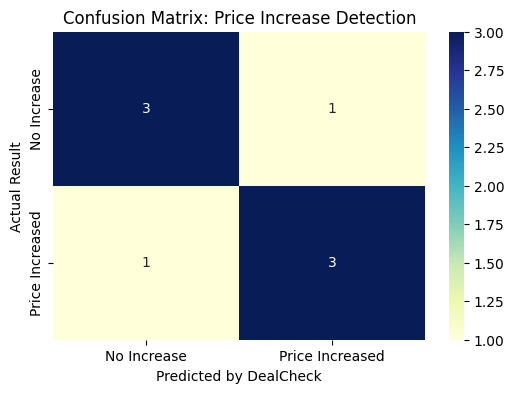

In [21]:
confusion_matrix = tf.math.confusion_matrix(
    y_true,
    y_pred,
    num_classes=2
).numpy()

print(confusion_matrix)

plt.figure(figsize=(6, 4))

sns.heatmap(
    confusion_matrix,
    annot=True,
    fmt="d",
    cmap="YlGnBu",
    xticklabels=["No Increase", "Price Increased"],
    yticklabels=["No Increase", "Price Increased"]
)

plt.xlabel("Predicted by DealCheck")
plt.ylabel("Actual Result")
plt.title("Confusion Matrix: Price Increase Detection")
plt.show()

In [23]:
accuracy_metric = tf.keras.metrics.BinaryAccuracy()

accuracy_metric.update_state(y_true, y_pred)

accuracy_score = accuracy_metric.result().numpy()

print("Accuracy Score:", round(accuracy_score, 3))

Accuracy Score: 0.75


## error analysis

In [24]:
error_analysis = evaluation_data

error_analysis["result"] = np.select(
    [
        (error_analysis["actual_label"] == 1) &
        (error_analysis["predicted_label"] == 1),

        (error_analysis["actual_label"] == 0) &
        (error_analysis["predicted_label"] == 0),

        (error_analysis["actual_label"] == 0) &
        (error_analysis["predicted_label"] == 1),

        (error_analysis["actual_label"] == 1) &
        (error_analysis["predicted_label"] == 0),
    ],
    [
        "True Positive",
        "True Negative",
        "False Positive",
        "False Negative",
    ],
    default="Unknown"
)

errors_only = error_analysis[
    error_analysis["result"].isin(["False Positive", "False Negative"])
]

print("Error Analysis:")
display(errors_only[["product", "actual_label", "predicted_label", "result"]])

print("\nNumber of each result:")
print(error_analysis["result"].value_counts())

Error Analysis:


,product,actual_label,predicted_label,result
4,Bread,1,0,False Negative
7,Coffee,0,1,False Positive



Number of each result:
result
True Positive     3
True Negative     3
False Negative    1
False Positive    1
Name: count, dtype: int64
